In [1]:
 #primero nuestras librerias!

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np
# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
from src import soporte_correlacion as sp_corr

In [3]:
df=pd.read_csv("files/world_data_full_apply_nulos.csv",index_col=0)

In [4]:
df.head()

,country,density,abbreviation,agricultural_land,land_area,armed_forces_size,birth_rate,calling_code,capital/major_city,co2-emissions,cpi,cpi_change,currency-code,fertility_rate,forested_area,gasoline_price,gdp,gross_primary_education_enrollment,gross_tertiary_education_enrollment,infant_mortality,largest_city,life_expectancy,maternal_mortality_ratio,minimum_wage,official_language,out_of_pocket_health_expenditure,physicians_per_thousand,population,population_labor_force_participation,tax_revenue,total_tax_rate,unemployment_rate,urban_population,latitude,longitude,continent
0,Afghanistan,60.0,AF,58.1,652.230,323.0,32.49,93.0,Kabul,8.672,149.90,2.3,AFN,4.47,2.1,0.70,1.910135e+10,104.0,9.7,47.9,Kabul,64.5,638.0,0.43,Pashto,78.4,0.28,NaN,48.9,9.3,71.4,11.12,NaN,33.939110,67.709953,Asia
1,Albania,105.0,AL,43.1,28.748,9.0,11.78,355.0,Tirana,4.536,119.05,1.4,ALL,1.62,28.1,1.36,1.527808e+10,107.0,55.0,7.8,Tirana,78.5,15.0,1.12,Albanian,56.9,1.20,NaN,55.7,18.6,36.6,12.33,NaN,41.153332,20.168331,Europe
2,Algeria,18.0,DZ,17.4,NaN,317.0,24.28,213.0,Algiers,150.006,151.36,2.0,DZD,3.02,0.8,0.28,1.699882e+11,109.9,51.4,20.1,Algiers,76.7,112.0,0.95,Arabic,28.1,1.72,NaN,41.2,37.2,66.1,11.70,NaN,28.033886,1.659626,Africa
3,Andorra,164.0,AD,40.0,468.000,NaN,7.20,376.0,Andorra la Vella,469.000,NaN,NaN,EUR,1.27,34.0,1.51,3.154058e+09,106.4,NaN,2.7,Andorra la Vella,NaN,NaN,6.63,Catalan,36.4,3.33,77.142,NaN,NaN,NaN,NaN,67.873,42.506285,1.521801,Europe
4,Angola,26.0,AO,47.5,NaN,117.0,40.73,244.0,Luanda,34.693,261.73,17.1,AOA,5.52,46.3,0.97,9.463542e+10,113.5,9.3,51.6,Luanda,60.8,241.0,0.71,Portuguese,33.4,0.21,NaN,77.5,9.2,49.1,6.89,NaN,-11.202692,17.873887,Africa


In [5]:
corr_1=df["fertility_rate"].corr(df["life_expectancy"])

print(corr_1)

-0.8491528107360005


<Axes: xlabel='fertility_rate', ylabel='life_expectancy'>

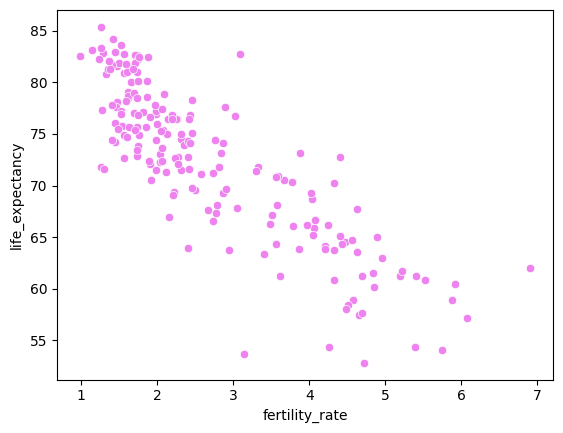

In [6]:
sns.scatterplot(data=df,x="fertility_rate",y="life_expectancy",color="violet")

In [7]:
#Se puede ver una correlación negativa muy fuerte entre la fertilidad y esperanza de vida.
#Mayor fertilidad----> menor esperanza de vida
#Menor esperanza ---- > mayor fertilidad

In [12]:
df.columns

Index(['country', 'density', 'abbreviation', 'agricultural_land', 'land_area',
       'armed_forces_size', 'birth_rate', 'calling_code', 'capital/major_city',
       'co2-emissions', 'cpi', 'cpi_change', 'currency-code', 'fertility_rate',
       'forested_area', 'gasoline_price', 'gdp',
       'gross_primary_education_enrollment',
       'gross_tertiary_education_enrollment', 'infant_mortality',
       'largest_city', 'life_expectancy', 'maternal_mortality_ratio',
       'minimum_wage', 'official_language', 'out_of_pocket_health_expenditure',
       'physicians_per_thousand', 'population',
       'population_labor_force_participation', 'tax_revenue', 'total_tax_rate',
       'unemployment_rate', 'urban_population', 'latitude', 'longitude',
       'continent'],
      dtype='str')

In [13]:
#2) PIB, emisiones y población: ¿qué se relaciona con qué?

lista_variables=["gdp","population","co2-emissions"]

In [14]:
matriz_cor=df[lista_variables].corr(numeric_only=True)
print(matriz_cor)

                    gdp  population  co2-emissions
gdp            1.000000    0.274346       0.479662
population     0.274346    1.000000      -0.168062
co2-emissions  0.479662   -0.168062       1.000000


<Axes: >

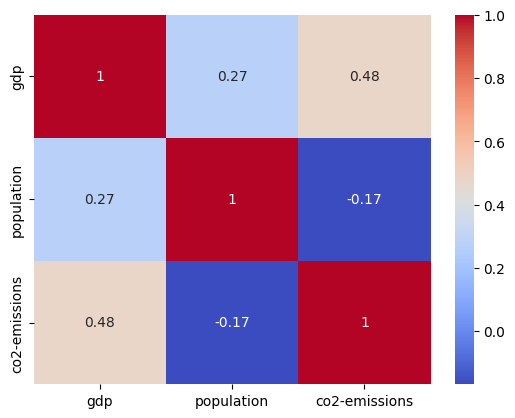

In [16]:
sns.heatmap(matriz_cor, annot=True, cmap='coolwarm')


entre poblacion y gdp hay una correlacion baja y positiva 



¿Qué par de variables tiene la correlación más alta? 
Entre emisiones y producto interno bruto hay una correlacion media positiva, a mayor gdp mayores emisiones

¿Tiene sentido desde el punto de vista económico/medioambiental? si, mayor gasto mayores emisiones

¿Hay algún par con correlación muy baja (cerca de 0)? ¿Qué interpretación darías?
entre poblacion y emisiones  hay una correlacion baja negativa entre ellas

3. Distribución de países por continente (variable categórica)
Variable categórica: continent

Calcula la tabla de frecuencias de continent:

Frecuencia absoluta (número de países por continente).

Frecuencia relativa o porcentaje sobre el total.

Interpreta:

¿Qué continente tiene más países en el dataset?

¿Qué continentes están menos representados?

Desde el punto de vista de un analista, ¿por qué es importante conocer esta distribución antes de comparar indicadores entre continentes?



In [ ]:
df["continent"].value_counts()
#La frecuencia absoluta de los paises

continent
Africa             53
Europe             47
Asia               45
Central America    20
Oceania            14
South America      13
North America       2
Name: count, dtype: int64

In [ ]:
(df["continent"].value_counts(normalize=True)*100).round(2)
#La frecuencia relativa de los paises

continent
Africa             27.32
Europe             24.23
Asia               23.20
Central America    10.31
Oceania             7.22
South America       6.70
North America       1.03
Name: proportion, dtype: float64

Podemos concluir que continente que tiene mas paises es Africa con 53 paises
El menos representado es NorteAmerica con 2 paises, que son el 1.03% de los paises. 

Desde el punto de vista de un analista, ¿por qué es importante conocer esta distribución antes de comparar indicadores entre continentes?
Porque hay que tener en cuenta la frecuencia relativa, comparar Africa con NorteAmerica no tiene sentido sin ver la fecuencia negativa. 

In [32]:
solo_africa = df[df["continent"] == "Africa"]

In [33]:
paises_de_africa = solo_africa["country"]

In [35]:
paises_unicos = paises_de_africa.nunique()
print(paises_unicos)

53


In [38]:
emisiones_africa = df.groupby("continent")["co2-emissions"].mean()

In [39]:
emisiones_africa

continent
Africa             121.426135
Asia               135.302585
Central America    152.865100
Europe             108.740524
North America      544.894000
Oceania            130.528615
South America       91.830462
Name: co2-emissions, dtype: float64

Hemos comprobado que Aunque Africa es el continente con mas paises, es uno de los que menos contribuye a las emisiones. Sin embargo Norte America que son 2 paises es el que mas contamina. 

Calcula la frecuencia absoluta y relativa de official_language.

Identifica:

Los 5 idiomas oficiales más frecuentes.

Interpreta:

¿Hay algún idioma claramente dominante?

¿Qué implicaciones podría tener esto a la hora de diseñar encuestas, campañas o informes internacionales?

(Si hay demasiadas categorías, puedes usar algo como value_counts().head(10) para ver solo las más frecuentes.)

4. Idioma oficial: ¿qué idiomas son más frecuentes?

In [40]:
df["official_language"].value_counts()
#La frecuencia absoluta de los idiomas

official_language
English              31
French               25
Spanish              19
Arabic               18
Portuguese            7
                     ..
Tuvaluan Language     1
Ukrainian             1
Uzbek                 1
Vietnamese            1
Shona                 1
Name: count, Length: 76, dtype: int64

In [ ]:
(df["official_language"].value_counts(normalize=True)*100).round(2)
#La frecuencia relativa de los idiomas

official_language
English              16.32
French               13.16
Spanish              10.00
Arabic                9.47
Portuguese            3.68
                     ...  
Tuvaluan Language     0.53
Ukrainian             0.53
Uzbek                 0.53
Vietnamese            0.53
Shona                 0.53
Name: proportion, Length: 76, dtype: float64

¿Hay algún idioma claramente dominante? Ingles, pero le sigue de cerca el frances y espanol. No es un dominio obvio

¿Qué implicaciones podría tener esto a la hora de diseñar encuestas, campañas o informes internacionales?
En general se hacen versiones en ingles de todos esos documentos

(Si hay demasiadas categorías, puedes usar algo como value_counts().head(10) para ver solo las más frecuentes.)

In [ ]:
En esta base de datos tenemos gdp (Producto Interno Bruto per cápita aproximado). Crea primero una variable categórica derivada a partir de gdp, por ejemplo:

bajo: países con gdp por debajo del percentil 33.

medio: entre los percentiles 33 y 66.

alto: por encima del percentil 66.

Puedes llamarla, por ejemplo, gdp_level.

Crea la nueva columna gdp_level en el DataFrame.

Construye una tabla de contingencia entre:

Filas: continent

Columnas: gdp_level

Normaliza la tabla por filas (porcentaje dentro de cada continente).

Interpreta:

¿Qué continentes concentran más países en el grupo de gdp alto?

¿Hay algún continente donde predominen claramente los países de gdp bajo?

¿Qué conclusiones preliminares (no definitivas) podrías extraer sobre la distribución de riqueza por continente?

In [42]:
df['gdp_level'] = pd.qcut(df['gdp'], 
                          q=[0, 0.33, 0.66, 1.0], 
                          labels=['bajo', 'medio', 'alto'])

In [43]:
(df["gdp_level"].value_counts(normalize=True)*100).round(2)

gdp_level
alto     34.20
bajo     33.16
medio    32.64
Name: proportion, dtype: float64

In [46]:
# Creamos la tabla de contingencia
tabla_gdp = pd.crosstab(df['continent'], df['gdp_level'], normalize='index')

# Multiplicamos por 100 para que sea más fácil de leer (porcentajes)
tabla_gdp = tabla_gdp * 100

print(tabla_gdp)

gdp_level             bajo      medio        alto
continent                                        
Africa           47.169811  37.735849   15.094340
Asia             15.909091  38.636364   45.454545
Central America  55.000000  30.000000   15.000000
Europe           15.217391  32.608696   52.173913
North America     0.000000   0.000000  100.000000
Oceania          78.571429   7.142857   14.285714
South America    15.384615  30.769231   53.846154
